In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
metadata_filepath = "../INPUT/01_metadata/metadata.csv"
basinatlas_filepath = "../INPUT/04_static_basinatlas_catchment_characteristics/static_basinatlas_catchment_characteristics.csv"
COMID_filepath = "../INPUT/00_geospatial_data/SWIM_gage_loc/SWIM_gage_loc.shp"
USSF_filepath = "../INPUT/00_geospatial_data/US_shapefiles/cb_2017_us_state_5m.shp"
basin_atlas_filepath = "../INPUT/00_geospatial_data/basin_atlas/"
temporal_summary_filepath = "../OUTPUT/temporal_statistics_mrb_usgs.csv"

In [3]:
# Match COMIDs from data retrieval
COMID = gpd.read_file(COMID_filepath)

C:\Users\danyk\anaconda3\envs\geospatialEnv\lib\site-packages\pyogrio\raw.py:196: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


In [4]:
# Reading and filtering 
basinatlas = pd.read_csv(basinatlas_filepath)
basinatlas = basinatlas[['STREAM_ID',
                         'clz_cl_smj', # Climate Zones (spatial maj)
                         'ari_ix_sav', # Aridity Index (spatial ave)
                         'kar_pc_sse', # Karst percentage (spatial extent %)
                         'ppd_pk_sav', # Pop density (pop km2; spatial ave)
                         'rdd_mk_sav', # Road Density (spatial ave)
                         'hft_ix_s09', # Human footprint (2009)
                         'slp_dg_sav', # Terrain slope
                         'lit_cl_smj', # Lith classes (spatial maj)
                         'ele_mt_sav'  # Average elevation
                        ]]

param_dict = {'clz_cl_smj_remap':'Climate Zones',
              'ari_ix_sav':'Aridity Index',
              'kar_pc_sse':'% Karst', 
              'ppd_pk_sav':'Pop. Density',
              'rdd_mk_sav':'Road Density',
              'hft_ix_s09':'Human footprint',
              'slp_dg_sav':'Terrain slope',
              'lit_cl_smj_remap':'Lithology classes',
              'ele_mt_sav':'Average elevation'}

# Converting to true values
basinatlas['ari_ix_sav'] = basinatlas['ari_ix_sav']/100
basinatlas['slp_dg_sav'] = basinatlas['slp_dg_sav']/10
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav
0,STREAM-gauge-1723,7.0,1.101513,0.0,12.129693,207.375630,77.930846,9.251775,3.0,633.409154
1,STREAM-gauge-2691,7.0,1.140810,0.0,23.310343,275.694486,103.656822,8.274755,3.0,591.319034


In [5]:
# Mapping cateogorical variables
clz_cl = pd.read_csv(basin_atlas_filepath+'clz_cl.csv')
clz_cl_dict = pd.Series(clz_cl.Reclassification.values, index=clz_cl.GEnZ_ID).to_dict()

lit_cl = pd.read_csv(basin_atlas_filepath+'lit_cl.csv')
lit_cl_dict = pd.Series(lit_cl.Reclassification.values, index=lit_cl.GLiM_ID).to_dict()

basinatlas['clz_cl_smj_remap'] = basinatlas['clz_cl_smj'].map(clz_cl_dict)
basinatlas['lit_cl_smj_remap'] = basinatlas['lit_cl_smj'].map(lit_cl_dict)
basinatlas.head(2)

,STREAM_ID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap
0,STREAM-gauge-1723,7.0,1.101513,0.0,12.129693,207.375630,77.930846,9.251775,3.0,633.409154,5,Sedimentary
1,STREAM-gauge-2691,7.0,1.140810,0.0,23.310343,275.694486,103.656822,8.274755,3.0,591.319034,5,Sedimentary


In [6]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath, dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")
params = ['SpC_uScm','DO_mgL','Turb_FNU']

for param in params:
    md_wide[param] = md_wide['WQ_parameters'].str.contains(param)

# Removing the stations without data
md_wide = md_wide[(md_wide['SpC_uScm']) | (md_wide['DO_mgL']) | (md_wide['Turb_FNU'])]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 870
Filtered dataset size: 556


In [7]:
md = md_wide.melt(
    id_vars=['STREAM_ID', 'sourceID', 'source', 'site name', 'latitude_wgs84', 
             'longitude_wgs84', 'drainagearea_sqkm', 'state_name', 'time_zone', 'WQ_parameters'],
    value_vars=['SpC_uScm', 'DO_mgL', 'Turb_FNU'],
    var_name='parameter',
    value_name='has_data'
)
md = md[md['has_data']].drop(['WQ_parameters','has_data'],axis=1)
md.sort_values('STREAM_ID').head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter
999,STREAM-gauge-1012,07214550,USGS,"MORA CREEK AT HOLMAN, NM",36.035217,-105.379983,NaN,New Mexico,Mountain,DO_mgL
1555,STREAM-gauge-1012,07214550,USGS,"MORA CREEK AT HOLMAN, NM",36.035217,-105.379983,NaN,New Mexico,Mountain,Turb_FNU
1556,STREAM-gauge-1013,07218525,USGS,"SAPELLO RIVER ABOVE SAPELLO, NM",35.772989,-105.304481,NaN,New Mexico,Mountain,Turb_FNU
1000,STREAM-gauge-1013,07218525,USGS,"SAPELLO RIVER ABOVE SAPELLO, NM",35.772989,-105.304481,NaN,New Mexico,Mountain,DO_mgL
864,STREAM-gauge-1042,06418800,USGS,"RAPID CREEK ABOVE WRF NR RAPID CITY, SD",44.026806,-103.101111,1163.915606,South Dakota,Mountain,DO_mgL


In [8]:
# Merge COMID 
md_comid = md.merge(COMID[['Gage_no','COMID']], 
              left_on='sourceID',
              right_on='Gage_no',
             how='left')
print(f"Filtered dataset size: {md_comid.shape[0]}")

Filtered dataset size: 1060


In [9]:
#md.to_csv('../OUTPUT/filtered_spC_DO_turb.csv')
md_comid.head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,Gage_no,COMID
0,STREAM-gauge-1723,03007800,USGS,"Allegheny River at Port Allegany, PA",41.818676,-78.292791,642.317520,Pennsylvania,Eastern,SpC_uScm,03007800,8972788.0
1,STREAM-gauge-1726,03016000,USGS,"Allegheny River at West Hickory, PA",41.570895,-79.407824,9479.363400,Pennsylvania,Eastern,SpC_uScm,03016000,10220190.0
2,STREAM-gauge-1733,03027500,USGS,"EB Clarion River at EB Clarion River Dam, PA",41.553118,-78.596135,189.587268,Pennsylvania,Eastern,SpC_uScm,03027500,6874115.0
3,STREAM-gauge-1736,03034000,USGS,"Mahoning Creek at Punxsutawney, PA",40.939231,-79.008367,409.218420,Pennsylvania,Eastern,SpC_uScm,03034000,4741709.0
4,STREAM-gauge-1738,03036000,USGS,"Mahoning Creek at Mahoning Creek Dam, PA",40.927565,-79.291151,890.956560,Pennsylvania,Eastern,SpC_uScm,03036000,166808422.0


In [10]:
md_spatial_data = md_comid.merge(basinatlas, on='STREAM_ID')
md_spatial_data.head()
#md_spatial_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams.csv')

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,Gage_no,COMID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap
0,STREAM-gauge-1723,03007800,USGS,"Allegheny River at Port Allegany, PA",41.818676,-78.292791,642.317520,Pennsylvania,Eastern,SpC_uScm,03007800,8972788.0,7.0,1.101513,0.000000,12.129693,207.375630,77.930846,9.251775,3.0,633.409154,5,Sedimentary
1,STREAM-gauge-1726,03016000,USGS,"Allegheny River at West Hickory, PA",41.570895,-79.407824,9479.363400,Pennsylvania,Eastern,SpC_uScm,03016000,10220190.0,7.0,1.207503,0.000000,27.085210,323.501430,106.949843,6.579398,3.0,543.494624,5,Sedimentary
2,STREAM-gauge-1733,03027500,USGS,"EB Clarion River at EB Clarion River Dam, PA",41.553118,-78.596135,189.587268,Pennsylvania,Eastern,SpC_uScm,03027500,6874115.0,7.0,1.216157,0.000000,1.794317,130.365008,39.261068,5.554338,3.0,626.424797,5,Sedimentary
3,STREAM-gauge-1736,03034000,USGS,"Mahoning Creek at Punxsutawney, PA",40.939231,-79.008367,409.218420,Pennsylvania,Eastern,SpC_uScm,03034000,4741709.0,10.0,1.155280,68.797004,43.181603,450.021916,131.517594,5.275403,3.0,488.056823,6,Sedimentary
4,STREAM-gauge-1738,03036000,USGS,"Mahoning Creek at Mahoning Creek Dam, PA",40.927565,-79.291151,890.956560,Pennsylvania,Eastern,SpC_uScm,03036000,166808422.0,10.0,1.157033,68.379352,28.583614,324.112753,109.585831,5.644361,3.0,471.156757,6,Sedimentary


In [11]:
# Merging the temporal data derived by Sai
temporal_summary = pd.read_csv(temporal_summary_filepath)

# Identify your ID/metadata columns (keep these as-is)
id_cols = ['STREAM_ID']

# Parameters you're tracking
temporal_params = ['WTemp_C', 'SpC_uScm', 'DO_mgL', 'pH', 'Turb_FNU', 'Turb_NTU',
          'NO3_mgNL', 'fDOM_QSU', 'fDOM_RFU', 'DOC_mgL', 'PO4_mgL', 
          'Chla_ugL', 'Chla_RFU', 'PC_ugL', 'PC_RFU']

# Reshape
rows = []
for temp_param in temporal_params:
    temp = temporal_summary[id_cols].copy()
    temp['parameter'] = temp_param
    temp['pct_missing'] = temporal_summary[f'{temp_param}_pct_missing']
    temp['length_hr'] = temporal_summary[f'{temp_param}_length_hr']
    temp['longest_hr'] = temporal_summary[f'{temp_param}_longest_hr']
    rows.append(temp)

temporal_summary_long = (
    pd.concat(rows, ignore_index=True)
    .query('parameter in @params')
    .dropna(how='all', subset=['pct_missing', 'length_hr', 'longest_hr'])
)
temporal_summary_long.head()

,STREAM_ID,parameter,pct_missing,length_hr,longest_hr
869,STREAM-gauge-1723,SpC_uScm,4.02,129087.0,9415.0
873,STREAM-gauge-1726,SpC_uScm,11.43,15742.0,4608.0
880,STREAM-gauge-1733,SpC_uScm,50.11,156566.0,4050.0
883,STREAM-gauge-1736,SpC_uScm,5.66,128415.0,7859.0
885,STREAM-gauge-1738,SpC_uScm,5.84,147785.0,7921.0


In [12]:
md_data = md_spatial_data.merge(temporal_summary_long, on=['STREAM_ID','parameter'])
md_data.to_csv('../OUTPUT/filtered_spC_DO_turb_basinparams_tempstats.csv')
md_data.head()

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,Gage_no,COMID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr
0,STREAM-gauge-1723,03007800,USGS,"Allegheny River at Port Allegany, PA",41.818676,-78.292791,642.317520,Pennsylvania,Eastern,SpC_uScm,03007800,8972788.0,7.0,1.101513,0.000000,12.129693,207.375630,77.930846,9.251775,3.0,633.409154,5,Sedimentary,4.02,129087.0,9415.0
1,STREAM-gauge-1726,03016000,USGS,"Allegheny River at West Hickory, PA",41.570895,-79.407824,9479.363400,Pennsylvania,Eastern,SpC_uScm,03016000,10220190.0,7.0,1.207503,0.000000,27.085210,323.501430,106.949843,6.579398,3.0,543.494624,5,Sedimentary,11.43,15742.0,4608.0
2,STREAM-gauge-1733,03027500,USGS,"EB Clarion River at EB Clarion River Dam, PA",41.553118,-78.596135,189.587268,Pennsylvania,Eastern,SpC_uScm,03027500,6874115.0,7.0,1.216157,0.000000,1.794317,130.365008,39.261068,5.554338,3.0,626.424797,5,Sedimentary,50.11,156566.0,4050.0
3,STREAM-gauge-1736,03034000,USGS,"Mahoning Creek at Punxsutawney, PA",40.939231,-79.008367,409.218420,Pennsylvania,Eastern,SpC_uScm,03034000,4741709.0,10.0,1.155280,68.797004,43.181603,450.021916,131.517594,5.275403,3.0,488.056823,6,Sedimentary,5.66,128415.0,7859.0
4,STREAM-gauge-1738,03036000,USGS,"Mahoning Creek at Mahoning Creek Dam, PA",40.927565,-79.291151,890.956560,Pennsylvania,Eastern,SpC_uScm,03036000,166808422.0,10.0,1.157033,68.379352,28.583614,324.112753,109.585831,5.644361,3.0,471.156757,6,Sedimentary,5.84,147785.0,7921.0


In [13]:
md_gdf = gpd.GeoDataFrame(md_data, 
                          geometry=gpd.points_from_xy(md_data.longitude_wgs84, md_data.latitude_wgs84), 
                          crs="EPSG:4326")
md_gdf.head(2)

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,parameter,Gage_no,COMID,clz_cl_smj,ari_ix_sav,kar_pc_sse,ppd_pk_sav,rdd_mk_sav,hft_ix_s09,slp_dg_sav,lit_cl_smj,ele_mt_sav,clz_cl_smj_remap,lit_cl_smj_remap,pct_missing,length_hr,longest_hr,geometry
0,STREAM-gauge-1723,03007800,USGS,"Allegheny River at Port Allegany, PA",41.818676,-78.292791,642.31752,Pennsylvania,Eastern,SpC_uScm,03007800,8972788.0,7.0,1.101513,0.0,12.129693,207.37563,77.930846,9.251775,3.0,633.409154,5,Sedimentary,4.02,129087.0,9415.0,POINT (-78.29279 41.81868)
1,STREAM-gauge-1726,03016000,USGS,"Allegheny River at West Hickory, PA",41.570895,-79.407824,9479.36340,Pennsylvania,Eastern,SpC_uScm,03016000,10220190.0,7.0,1.207503,0.0,27.085210,323.50143,106.949843,6.579398,3.0,543.494624,5,Sedimentary,11.43,15742.0,4608.0,POINT (-79.40782 41.5709)


## Exploring spatial patterns 

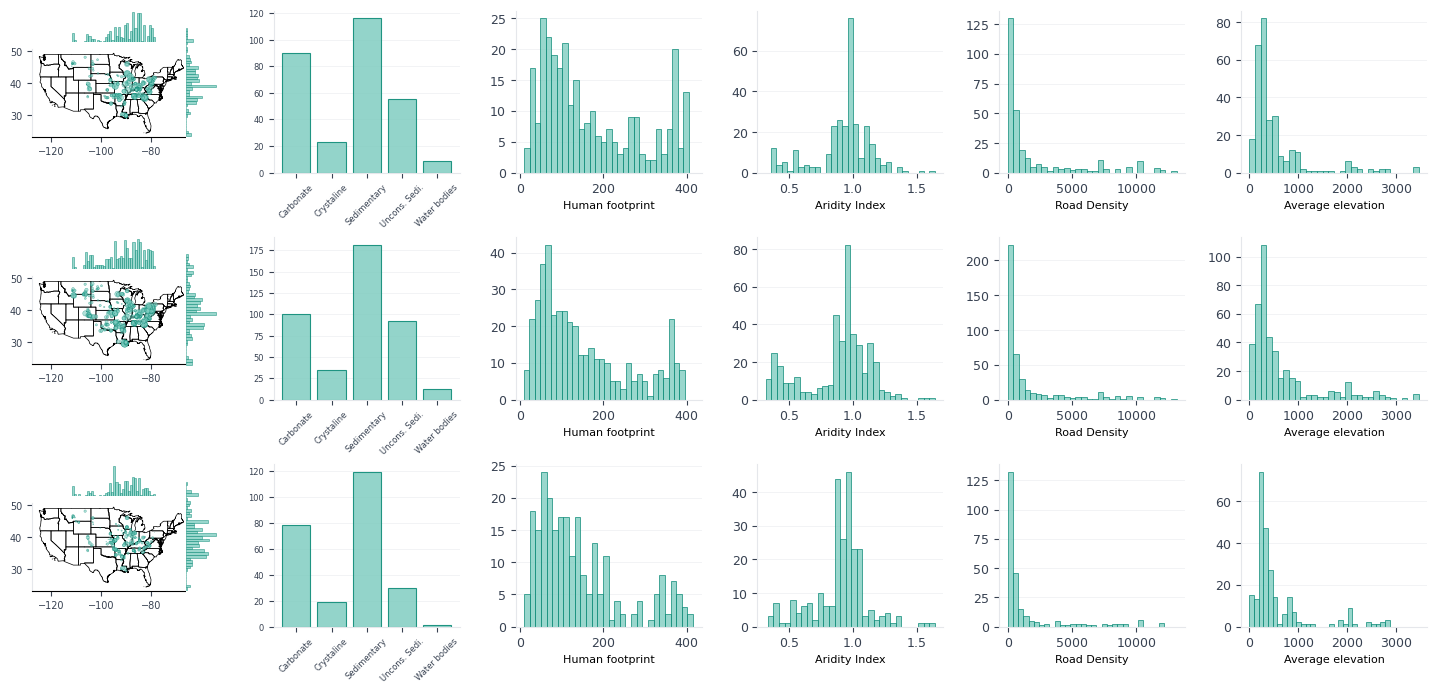

In [14]:
# Anxillary files
US_shp = gpd.read_file(USSF_filepath)

# Colour pallette
MAP_COLOR = '#2563EB'
HIST_COLOR = '#80cdc1'
HIST_EDGE = '#018571'
BG_COLOR = '#FFFFFF'
GRID_COLOR = '#E5E7EB'

params = {
    'DO_mgL': 'DO',
    'SpC_uScm': 'Cond.',
    'Turb_FNU': 'Turb.'
}

vars_cat = ['lit_cl_smj_remap']
vars_cont = ['hft_ix_s09', 'ari_ix_sav', 'rdd_mk_sav', 'ele_mt_sav']

# Shared x-axis limits for histograms
shared_xlims = {}
for var in vars_cont:
    global_min = md_gdf[var].min()
    global_max = md_gdf[var].max()
    margin = (global_max - global_min) * 0.05
    shared_xlims[var] = (global_min - margin, global_max + margin)
    
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(3, 6, hspace=0.4, wspace=0.3)

for j, (param_col, param_label) in enumerate(params.items()):
    md_gdf_filt = md_gdf[md_gdf['parameter'] == param_col]

    # --- Map with marginal distributions ---
    # Sub-gridspec for map cell (top-left)
    gs_map = gs[j, 0].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5], 
                                  hspace=-0.3, wspace=-0.05)
    
    ax_map = fig.add_subplot(gs_map[1, 0])
    ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
    ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

    # Main map
    US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
    md_gdf_filt.plot(ax=ax_map,
                     color=HIST_COLOR, 
                     markersize=md_gdf_filt['longest_hr'] / 1000,
                     alpha=0.6, 
                     edgecolor=HIST_EDGE, 
                     linewidth=0.3)
    ax_map.tick_params(labelsize=7, colors='#374151')
    ax_map.spines[['top', 'right']].set_visible(False)
    ax_map.spines[['top', 'left']].set_color(GRID_COLOR)

    # Longitude distribution (top)
    lons = md_gdf_filt.geometry.x
    lats = md_gdf_filt.geometry.y
    ax_top.hist(lons, bins=40, color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
    #ax_top.set_title(f'Stations with ≥1 meas. of {param_label}',
    #                 fontsize=10, fontweight='bold', pad=6)
    ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Latitude distribution (right)
    ax_right.hist(lats, bins=40, orientation='horizontal',
                  color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
    ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # --- Bar chart ---
    cntr = 1
    ax_bar = fig.add_subplot(gs[j, 1])
    for i, var in enumerate(vars_cat):
        cntr += 1
        counts = md_gdf_filt[var].value_counts().sort_index()
        ax_bar.bar(counts.index, counts.values,
                   color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.8, alpha=0.85)
        #ax_bar.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        #ax_bar.set_xlabel(param_dict[var], fontsize=8)
        ax_bar.set_facecolor(BG_COLOR)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.spines[['left', 'bottom']].set_color(GRID_COLOR)
        ax_bar.tick_params(colors='#374151', labelsize=6)
        ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax_bar.set_axisbelow(True)
        ax_bar.tick_params(axis='x', rotation=45)

    # --- Histograms (remaining slots) ---
    hist_positions = [(j, 2), (j, 3), (j, 4), (j, 5)]
    for i, var in enumerate(vars_cont):
        row, col = hist_positions[i]
        a = fig.add_subplot(gs[row, col])
        a.hist(md_gdf_filt[var], bins=30,
               color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.6, alpha=0.8)
        a.set_xlim(shared_xlims[var])
        #a.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        a.set_xlabel(param_dict[var], fontsize=8)
        a.set_facecolor(BG_COLOR)
        a.spines[['top', 'right']].set_visible(False)
        a.spines[['left', 'bottom']].set_color(GRID_COLOR)
        a.tick_params(colors='#374151', labelsize=9)
        a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        a.set_axisbelow(True)
    
    #plt.savefig(f'../OUTPUT/spatial_patterns/{param_col}_spatial_distributions.png', dpi=600, bbox_inches='tight')

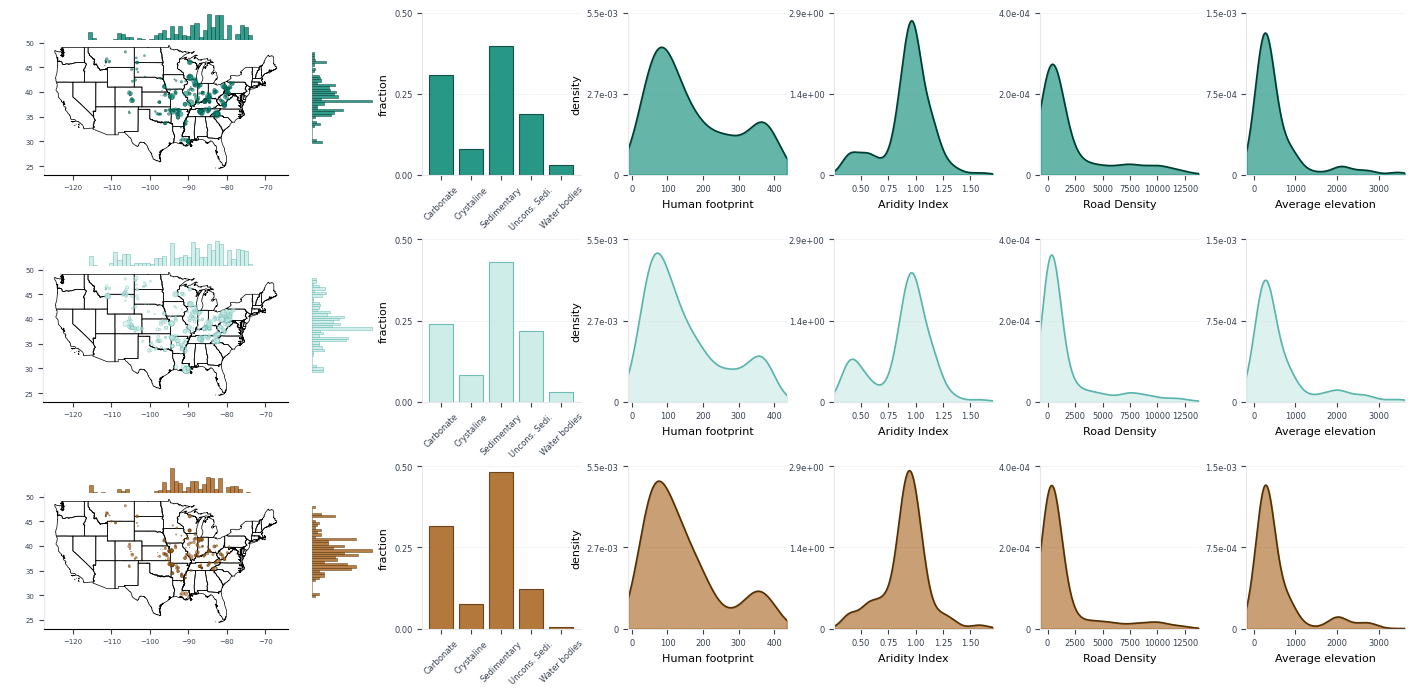

In [15]:
from scipy.stats import gaussian_kde
import numpy as np

shared_ylims = {
    'lit_cl_smj_remap': 0.5,
    'hft_ix_s09': 0.0055,
    'ari_ix_sav': 2.9,
    'rdd_mk_sav': 0.0004,
    'ele_mt_sav': 0.0015
}

PARAM_COLORS = {
    'DO_mgL':    {'fill': '#018571', 'edge': '#003c30'},  # current teal
    'SpC_uScm':  {'fill': '#c7eae5', 'edge': '#5ab4ac'},  # blue
    'Turb_FNU':  {'fill': '#a6611a', 'edge': '#543005'},  # steel blue
}

# Shared x-axis limits for histograms
shared_xlims = {}
for var in vars_cont:
    global_min = md_gdf[var].min()
    global_max = md_gdf[var].max()
    margin = (global_max - global_min) * 0.05
    shared_xlims[var] = (global_min - margin, global_max + margin)
    
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(3, 7, hspace=0.4, wspace=0.3)

for j, (param_col, param_label) in enumerate(params.items()):

    fill_color = PARAM_COLORS[param_col]['fill']
    edge_color = PARAM_COLORS[param_col]['edge']
    md_gdf_filt = md_gdf[md_gdf['parameter'] == param_col]

    # --- Map with marginal distributions ---
    # Sub-gridspec for map cell (top-left)
    gs_map = gs[j, 0:2].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                 hspace=0, wspace=-0.05)
    
    ax_map = fig.add_subplot(gs_map[1, 0])
    ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
    ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

    # Main map
    US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
    md_gdf_filt.plot(ax=ax_map,
                     color=fill_color, 
                     markersize=md_gdf_filt['longest_hr'] / 1000,
                     alpha=0.6, 
                     edgecolor=edge_color, 
                     linewidth=0.3)
    ax_map.tick_params(labelsize=5, colors='#374151')
    ax_map.spines[['top', 'right']].set_visible(False)
    ax_map.spines[['top', 'left']].set_color(GRID_COLOR)
    

    # Longitude distribution (top)
    lons = md_gdf_filt.geometry.x
    lats = md_gdf_filt.geometry.y
    ax_top.hist(lons, bins=40, color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    #ax_top.set_title(f'Stations with ≥1 meas. of {param_label}',
    #                 fontsize=10, fontweight='bold', pad=6)
    ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # Latitude distribution (right)
    ax_right.hist(lats, bins=40, orientation='horizontal',
                  color=fill_color, edgecolor=edge_color, linewidth=0.4, alpha=0.8)
    ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
    ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    # --- Bar chart ---
    cntr = 1
    ax_bar = fig.add_subplot(gs[j, 2])
    for i, var in enumerate(vars_cat):
        cntr += 1
        counts = md_gdf_filt[var].value_counts().sort_index()
        ax_bar.bar(counts.index, counts.values/(counts.values.sum()),
                   color=fill_color, edgecolor=edge_color, linewidth=0.8, alpha=0.85)
        #ax_bar.set_title(param_dict[var], fontsize=11, fontweight='bold', pad=10)
        #ax_bar.set_xlabel(param_dict[var], fontsize=8)
        ax_bar.set_ylabel('fraction', fontsize=8)
        ax_bar.set_ylim(0, shared_ylims[var])
        ax_bar.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        
        ax_bar.set_facecolor(BG_COLOR)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.spines[['left', 'bottom']].set_color(GRID_COLOR)
        ax_bar.tick_params(colors='#374151', labelsize=6)
        ax_bar.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        ax_bar.set_axisbelow(True)
        ax_bar.tick_params(axis='x', rotation=45)

    # --- Histograms (remaining slots) ---
    hist_positions = [(j, 3), (j, 4), (j, 5), (j, 6)]
    for i, var in enumerate(vars_cont):
        row, col = hist_positions[i]
        a = fig.add_subplot(gs[row, col])
        data = md_gdf_filt[var].dropna()
        kde = gaussian_kde(data)
        x_range = np.linspace(shared_xlims[var][0], shared_xlims[var][1], 300)
        a.fill_between(x_range, kde(x_range), color=fill_color, alpha=0.6)
        a.plot(x_range, kde(x_range), color=edge_color, linewidth=1.2)
        a.set_xlim(shared_xlims[var])
        a.set_xlabel(param_dict[var], fontsize=8)
        a.set_facecolor(BG_COLOR)
        a.spines[['top', 'right']].set_visible(False)
        a.spines[['left', 'bottom']].set_color(GRID_COLOR)
        a.tick_params(colors='#374151', labelsize=6)
        a.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
        a.set_axisbelow(True)
        
        if i == 0:
            a.set_ylabel('density', fontsize=8)

        a.set_ylim(0, shared_ylims[var])
        a.set_yticks([0, shared_ylims[var]/2, shared_ylims[var]])
        a.set_yticklabels(['0', f'{shared_ylims[var]/2:.1e}', f'{shared_ylims[var]:.1e}'], fontsize=6)
        
plt.savefig(f'../OUTPUT/spatial_patterns/parameter_spatial_distributions.png', dpi=600, bbox_inches='tight')

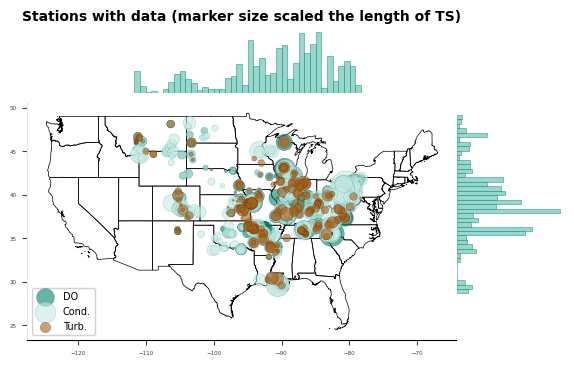

In [16]:
# Map with all analytes on it
# Create gridspec: map with marginal histograms + bar + 4 histograms
fig = plt.figure(figsize=(25, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

# --- Map with marginal distributions ---
# Sub-gridspec for map cell (top-left)
gs_map = gs[0, 0].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], 
                              hspace=0.0, wspace=0.0)

ax_map = fig.add_subplot(gs_map[1, 0])
ax_top = fig.add_subplot(gs_map[0, 0], sharex=ax_map)
ax_right = fig.add_subplot(gs_map[1, 1], sharey=ax_map)

# Main map
US_shp.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)
for param_col, colors in PARAM_COLORS.items():
    subset = md_gdf[md_gdf['parameter'] == param_col]
    subset.plot(ax=ax_map,
                color=colors['fill'],
                markersize=subset['longest_hr'] / 100,
                alpha=0.6,
                edgecolor=colors['edge'],
                linewidth=0.3,
                label=params[param_col])

ax_map.legend(fontsize=7, loc='lower left', framealpha=0.9)
ax_map.tick_params(labelsize=4, colors='#374151')
ax_map.spines[['top', 'right']].set_visible(False)
ax_map.spines[['top', 'left']].set_color(GRID_COLOR)

# Longitude distribution (top)
lons = md_gdf.geometry.x
lats = md_gdf.geometry.y
ax_top.hist(lons, bins=40, color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
ax_top.set_title(f'Stations with data (marker size scaled the length of TS)',
                 fontsize=10, fontweight='bold', pad=6)
ax_top.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
ax_top.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Latitude distribution (right)
ax_right.hist(lats, bins=40, orientation='horizontal',
              color=HIST_COLOR, edgecolor=HIST_EDGE, linewidth=0.4, alpha=0.8)
ax_right.tick_params(labelbottom=False, labelleft=False, left=False, bottom=False)
ax_right.spines[['top', 'right', 'left', 'bottom']].set_visible(False)